## Corrective RAG

**Corrective RAG (CRAG)** is an advanced technique within **Retrieval Augmented generation (RAG)** which focuses on improving the accuracy and relevance of generated responses by incorporating mechanisms for self-reflection and self-grading of retrieved documents. It does this by evaluating the quality of retrieved documents and applying corrective actions when necessary, such as refining or replacing incorrect retrievals.

#### Addressing limitations of Basic RAGs
Traditional RAG systems rely heavily on the accuracy of the retrieved documents. If the retrieved information is flawed or incomplete, the generated response can also be inaccurate.

#### CRAG Core Components
1. **Retrieval Evaluator**: This component assesses the quality and relevance of retrieved documents.
2. **Generative Model**: This model generates the initial response based on the retrieved information.
3. **Refinement and Correction**: CRAG employs strategies like knowedge refinement or web search to address issues identified by the retrieval evaluator.

### Benefits of CRAG

1. **Improved Accuracy**: By evaluating and correcting retrieved information, CRAG helps ensure the accuracy of generated responses.
2. **Enhanced Relevance**: CRAG can identify and filter out irrelevant information, making the generated response more relevant.
3. **Increased Robustness**: CRAG can handle cases where the initial retrieval process is not perfect, leading to more robust RAG system. 

In [8]:
import os
from dotenv import load_dotenv

env_path = '.env'
assert os.path.exists(env_path)

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

TAVILY_API_KEY = os.environ['TAVILY_API_KEY']
assert TAVILY_API_KEY
print(f'TAVILY_API_KEY: {TAVILY_API_KEY[:3]}**{TAVILY_API_KEY[-3:]}')

## Langsmith for debuging and tracing
LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}**{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
LANGCHAIN_TRACING_V2= os.environ['LANGCHAIN_TRACING_V2']
print(f'LANGCHAIN_TRACING_V2: {LANGCHAIN_TRACING_V2}')

LANGCHAIN_PROJECT = os.environ['LANGCHAIN_PROJECT']
print(f'LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA
TAVILY_API_KEY: tvl**66J
LANGCHAIN_API_KEY: lsv**43b
LANGCHAIN_TRACING_V2: true
LANGCHAIN_PROJECT: Agentic RAG tutorial


### Build Index (Vector store DB)

In [9]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# Embeddings
embeddings = OllamaEmbeddings(model='Gemma:2b')

# Document URLs
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm'
]

# Text splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

# Loader 
loader = WebBaseLoader(web_paths=urls)
docs = loader.load_and_split(text_splitter=text_splitter)

# Create Vector database
vector_store = FAISS.from_documents(documents=docs, embedding=embeddings)
retriever = vector_store.as_retriever()
retriever

USER_AGENT environment variable not set, consider setting it to identify your requests.


VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x11739f0e0>, search_kwargs={})

In [10]:
# Retrieval Grader

from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents
    """
    binary_outcome: Literal['yes', 'no'] = Field(description='Documets are relevant to the question')
    confidence: float = Field(description="""How confident the model is on document relevance.
                              A coefficient number between 0 and 1.
                              0 - Documents are NOT relevant to the question at all.
                              1 - Documents are completelly relevant to the question.
                              """)

# Create the LLM 
llm = ChatOpenAI(model='gpt-4.1')
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt 
system_prompt = """You are a grader assessing relevance of a retrieved document to a user question.\n
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.\n
Give a binary score ('yes' or 'no') to indicate if the document is relevant or not.\n
Give also a confidence - a number between 0 and 1 to indicate how relevant the document is to the question.
""" 

grade_prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Document content:\n{context}\n\n\nUser question: {question}\n')
])

retrieval_grader_chain = grade_prompt | structured_llm_grader

question = 'Prompt engineering'
docs = retriever.invoke(input=question)

context = docs[0].page_content
grade: GradeDocuments = retrieval_grader_chain.invoke(input={
    'context': context,
    'question': question
})
print(f'Grade: {grade}')
print(f'Context: {context}')

Grade: binary_outcome='yes' confidence=0.8
Context: One simple and intuitive way to defend the model against adversarial attacks is to explicitly instruct model to be responsible, not generating harmful content (Xie et al. 2023). It can largely reduce the success rate of jailbreak attacks, but has side effects for general model quality due to the model acting more conservatively (e.g. for creative writing) or incorrectly interpreting the instruction under some scenarios (e.g. safe-unsafe classification).


In [12]:
# Generate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import Runnable

# Prompt
prompt = hub.pull('rlm/rag-prompt')

# LLM
llm = ChatOpenAI(model='gpt-4.1')

# RAG chain
rag_chain: Runnable = prompt | llm | StrOutputParser()

# Postprocess
def format_docs(docs):
    return '\n\n'.join([doc.page_content for doc in docs])

# Run
generation = rag_chain.invoke(input={
    'context': format_docs(docs),
    'question': question
})
print(generation)

Prompt engineering is the practice of designing and refining input prompts to guide language models toward desired outputs. It can involve explicitly instructing the model to behave responsibly or incorporating external knowledge for more accurate and up-to-date responses. Effective prompt engineering can improve model performance and safety, but may sometimes lead to more conservative or misinterpreted outputs.


In [13]:
from langchain.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain import hub

# Prompt
rag_prompt = hub.pull('rlm/rag-prompt')
print(rag_prompt)

# Prompt
system_prompt = """You are question re-writer, who converts an input question to a better
version which is optimized for web search. Look at the input question and try to reason about
the underlying semantic intent/meaning"""
rewriter_promtp = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Input question: {question}\n\n')
])

print(rewriter_promtp)

input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]
input_variables=['question'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are question re-writer, who converts an input question to a better\nversion which is optimized for web search.

## Create the Graph

In [14]:
# Question Re-writer

# LLM
llm = ChatOpenAI(model='gpt-4.1', temperature=0)

# Prompt
system_prompt = """You are question re-writer, who converts an input question to a better
version which is optimized for web search. Look at the input question and try to reason about
the underlying semantic intent/meaning"""
rewriter_promtp = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', 'Input question: {question}\n\n')
])

rewriter_chain = rewriter_promtp | llm | StrOutputParser()
response = rewriter_chain.invoke(input={
    'question': 'What is Prompt engineering?'
})
response

'Rewritten question: What does prompt engineering mean and how is it used in AI and machine learning?'

## Web based seacrh

After we rewrite the question to be optimized for Web search, we need to hit a LLM with the new query.

In [15]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)
web_search_tool

/var/folders/g9/x11cjlw56ln82_76czqsvqvr0000gn/T/ipykernel_84076/553480457.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

## Create the Graph

In [32]:
from typing_extensions import TypedDict
from typing import List
from langchain_core.documents import Document

class GraphState(TypedDict):
    """Represents the state of the graph
    Attributes:
        question: initial question
        generation: generated from LLM
        web_search: optimized search
        documents: list of documents 
    """
    question: str
    generation: str
    web_search: str
    documents: List[str]

def retrieve(state: GraphState) -> GraphState:
    """Retrieve documents node

    Args:
        state (GraphState): Current state

    Returns:
        GraphState: Updated state
    """
    print('---Retrieve---')
    question = state['question']

    # Retrieval
    documents = retriever.invoke(question)
    return { 'question': question, 'documents': [doc.page_content for doc in documents] }

def generate(state: GraphState) -> GraphState:
    """Generate answer

    Args:
        state (GraphState): The current state

    Returns:
        GraphState: Updated state
    """
    print('---Generate---')
    documents: List[str] = state['documents']
    context = '\n\n'.join([doc for doc in documents])
    question = state['question']

    # RAG Generation
    generation: str = rag_chain.invoke(input={
        'question': question,
        'context': context
    })

    return { 'generation': generation, 'documents': state['documents'], 'question': state['question'] }


def grade_documents(state: GraphState) -> GraphState:
    """Determines if the retrieved documents are relevant to the question or not.

    Args:
        state (GraphState): The current state
    """
    print('---Check documents relevance---')
    documents: List[str] = state['documents']
    question = state['question']

    filtered_docs: List[str] = []

    for document in documents:
        score: GradeDocuments = retrieval_grader_chain.invoke(input={
            'context': document,
            'question': question
        })

        if score.binary_outcome == 'yes':
            print(f'---Document is relevant with confidence: {score.confidence}---')
            filtered_docs.append(document)
            print('---Document is added to filetered documents---')
        else:
            print(f'---Document is NOT relevant with confidence: {score.confidence}---')
    
    return { 'question': state['question'],
             'documents': filtered_docs, 
             'web_search': 'Yes' if len(filtered_docs) == 0 else 'No' }

def transform_query(state: GraphState) -> GraphState:
    """Transform question to produce better question optimized for Web search.

    Args:
        state (GraphState): The current state

    Returns:
        GraphState: Updated state
    """

    question = state['question']

    rewritten_question = rewriter_chain.invoke(input={
        'question': question
    })

    return { 'question': rewritten_question, 'documents': state['documents'] }

def web_search(state: GraphState) -> GraphState:
    """Web search based on rephrased question.

    Args:
        state (GraphState): Current state

    Returns:
        GraphState: Updated state
    """
    print('---Web search---')
    question = state['question']
    documents = state['documents']

    # Web seach
    docs = web_search_tool.invoke(input={'question': question})
    web_results = '\n'.join([d['content'] for d in docs])
    documents.append(web_results)

    return { 'question': state['question'], 'documents': documents }

In [33]:
## Edges
def decide_to_generate(state: GraphState) -> str:
    """Decide if we need to generate an answer or re-write the question.


    Args:
        state (GraphState): Graph current state

    Returns:
        str: Binary decision for next node to call
    """
    print('---Asses graded document---')
    web_search = state['web_search']

    if web_search == 'Yes':
        print('---DECISION: No documents relevant to the question, Re-write the question---')
        return 'transform_query'
    
    print('---DECISION: Generate---')
    return 'generate'

## Create the Graph

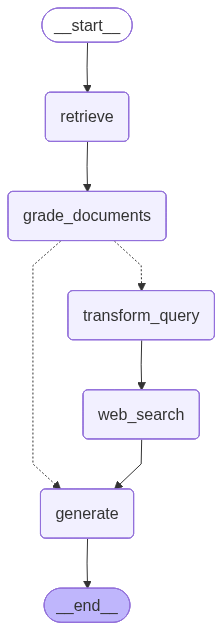

In [34]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph_builder = StateGraph(GraphState)
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('transform_query', transform_query)
graph_builder.add_node('grade_documents', grade_documents)
graph_builder.add_node('web_search', web_search)

# Add edges
graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'grade_documents')
graph_builder.add_conditional_edges('grade_documents', decide_to_generate,
                                    {
                                        'transform_query': 'transform_query',
                                        'generate': 'generate'
                                    })
graph_builder.add_edge('transform_query', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
initial_state: GraphState = { 'question': 'What are the types of agent memory?' }
result_state = graph.invoke(input=initial_state)
result_state

---Retrieve---
---Check documents relevance---
---Document is relevant with confidence: 1.0---
---Document is added to filetered documents---
---Document is relevant with confidence: 0.8---
---Document is added to filetered documents---
---Document is relevant with confidence: 1.0---
---Document is added to filetered documents---
---Document is relevant with confidence: 0.7---
---Document is added to filetered documents---
---Asses graded document---
---DECISION: Generate---
---Generate---


{'question': 'What are the types of agent memory?',
 'generation': 'The types of agent memory are sensory memory (which encodes raw input representations), short-term memory (in-context learning restricted by a finite window), and long-term memory (external storage accessed via retrieval). These map to sensory, short-term, and long-term human memory systems, respectively. Long-term memory can be further divided into explicit (facts and events) and implicit (skills) memory types.',
 'web_search': 'No',
 'documents': ['Categorization of human memory.\n\nWe can roughly consider the following mappings:\n\nSensory memory as learning embedding representations for raw inputs, including text, image or other modalities;\nShort-term memory as in-context learning. It is short and finite, as it is restricted by the finite context window length of Transformer.\nLong-term memory as the external vector store that the agent can attend to at query time, accessible via fast retrieval.',
  'Comparison of